# FNO for McKean-Vlasov

Learns the operator W(x) -> rho(x,t) for the 1D McKean-Vlasov equation on [0,1) x [0,T].
Input: interaction potential W, shape (N,).
Output: density rho, shape (N, N) (space x time).

In [69]:
# Imports
import numpy as np
import sys

import torch
from torch.utils.data import DataLoader, TensorDataset

import neuralop
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.utils import count_model_params
from torch.nn import functional as F

import matplotlib.pyplot as plt
from McKean_Vlasov_data import load_dataset_mckean_vlasov, get_resolution


In [70]:
# ===== HYPERPARAMETERS =====

# === Data ===
data_n_train        = 800
data_n_test         = 200
data_train_resolution = 64   # NX = NT = 64, so spacetime grid is 64x64
data_test_resolutions = [64, 128]
data_batch_size       = 32
data_test_batch_sizes = [32, 32]

# === Model ===
# Input:  W(x)    shape (batch, 1, N)     -- 1D spatial field
# Output: rho(x,t) shape (batch, 1, N, N) -- 2D spacetime field
# We treat the problem as 2D: space x time
FNO_n_modes          = (24, 24)  # Fourier modes in (space, time)
FNO_in_channels      = 1
FNO_out_channels     = 1
FNO_hidden_channels  = 32
FNO_n_layers         = 4
FNO_factorization    = "tucker"
FNO_nonlinearity     = F.gelu

# === Training ===
TRAIN_epochs = 500


In [71]:
def make_data_loader(W, rho, batch_size, shuffle=True):
    N = rho.shape[1]
    W_expanded = np.repeat(W[:, np.newaxis, :, np.newaxis], N, axis=3)
    rho_out    = rho[:, np.newaxis, :, :]

    x = torch.tensor(W_expanded, dtype=torch.float32)
    y = torch.tensor(rho_out,    dtype=torch.float32)

    def collate_fn(batch):
        xs = torch.stack([b[0] for b in batch])
        ys = torch.stack([b[1] for b in batch])
        return {"x": xs, "y": ys}

    dataset = TensorDataset(x, y)
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle,
                      num_workers=1, pin_memory=True,
                      persistent_workers=False, collate_fn=collate_fn)

In [72]:
# Activate GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [73]:
# Load McKean-Vlasov dataset
dataset = load_dataset_mckean_vlasov("mckean_vlasov_dataset.npz")

# Training data at train resolution
W_all, rho_all = get_resolution(dataset, data_train_resolution)

W_train   = W_all[:data_n_train]
rho_train = rho_all[:data_n_train]
W_test    = W_all[data_n_train:data_n_train + data_n_test]
rho_test  = rho_all[data_n_train:data_n_train + data_n_test]

train_loader = make_data_loader(W_train, rho_train, data_batch_size, shuffle=True)

test_loaders = {}
for res, bsize in zip(data_test_resolutions, data_test_batch_sizes):
    W_r, rho_r = get_resolution(dataset, res)
    W_t   = W_r[data_n_train:data_n_train + data_n_test]
    rho_t = rho_r[data_n_train:data_n_train + data_n_test]
    test_loaders[res] = make_data_loader(W_t, rho_t, bsize, shuffle=False)

print(f"Train: W {W_train.shape}, rho {rho_train.shape}")
print(f"Test resolutions: {list(test_loaders.keys())}")


Train: W (800, 64), rho (800, 64, 64)
Test resolutions: [64, 128]


In [74]:
# Instantiate Model
# FNO maps (batch, 1, N, N) -> (batch, 1, N, N)
# Input channel: W(x) broadcast over time axis
# Output channel: rho(x, t)
model = FNO(
    n_modes=FNO_n_modes,
    in_channels=FNO_in_channels,
    out_channels=FNO_out_channels,
    hidden_channels=FNO_hidden_channels,
    n_layers=FNO_n_layers,
    factorization=FNO_factorization,
    non_linearity=FNO_nonlinearity,
)

model = model.to(device)
n_params = count_model_params(model)
print(f"Model parameters: {n_params}")
sys.stdout.flush()

optimizer = AdamW(model.parameters(), lr=8e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses = {"h1": h1loss, "l2": l2loss}


Model parameters: 2591401


In [75]:
# Train model
trainer = Trainer(
    model=model,
    n_epochs=TRAIN_epochs,
    device=device,
    data_processor=None,
    wandb_log=False,
    eval_interval=5,
    use_distributed=False,
    verbose=True,
)

torch.serialization.add_safe_globals([torch._C._nn.gelu])
torch.serialization.add_safe_globals([neuralop.layers.spectral_convolution.SpectralConv])

# Train from scratch:
trainer.train(
    train_loader=train_loader,
    test_loaders={},
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=train_loss,
    save_every=5,
    save_dir="./checkpoints",
)

# To resume from checkpoints instead, comment above and uncomment below:
# trainer.train(
#     train_loader=train_loader,
#     test_loaders={},
#     optimizer=optimizer,
#     scheduler=scheduler,
#     regularizer=False,
#     training_loss=train_loss,
#     resume_from_dir="./checkpoints",
#     save_dir="./checkpoints",
# )


Training on 800 samples
Testing on [] samples         on resolutions [].
Raw outputs of shape torch.Size([32, 1, 64, 64])
[0] time=1.22, avg_loss=0.8603, train_err=27.5285
Eval: 
[Rank 0]: saved training state to ./checkpoints
[5] time=1.06, avg_loss=0.5664, train_err=18.1264
Eval: 
[Rank 0]: saved training state to ./checkpoints
[10] time=1.08, avg_loss=0.5119, train_err=16.3800
Eval: 
[Rank 0]: saved training state to ./checkpoints
[15] time=0.99, avg_loss=0.4758, train_err=15.2267
Eval: 
[Rank 0]: saved training state to ./checkpoints
[20] time=0.96, avg_loss=0.4219, train_err=13.5004
Eval: 
[Rank 0]: saved training state to ./checkpoints
[25] time=1.14, avg_loss=0.3831, train_err=12.2600
Eval: 
[Rank 0]: saved training state to ./checkpoints
[30] time=1.04, avg_loss=0.3721, train_err=11.9087
Eval: 
[Rank 0]: saved training state to ./checkpoints
[35] time=0.91, avg_loss=0.3755, train_err=12.0147
Eval: 
[Rank 0]: saved training state to ./checkpoints
[40] time=1.03, avg_loss=0.4121,

{'train_err': 2.4084350872039795,
 'avg_loss': 0.07526359647512436,
 'avg_lasso_loss': None,
 'epoch_train_time': 0.9657730299986724}

In [76]:
# === MCMC HYPERPARAMETERS ===
MCMC_delta = 0.0025  # can experiment later with adaptive delta, as in it gets smaller as the number of iterations increases.
MCMC_n_iterations = 20_000  # Most likely need it on the order of 100,000 to get good results, but we can test the code with fewer iterations first.
MCMC_tau = -1  # Smoothing parameter for the smooth threshold function. Higher values make it closer to a hard threshold, while lower values make it smoother. We can experiment with different values to see how it affects the results.


In [77]:
# MCMC helper functions

from McKean_Vlasov_data import sample_negative_laplacian

def log_likelihood(W_tensor: torch.Tensor, rho_obs: torch.Tensor,
                   model, sigma=0.1) -> float:
    """
    W_tensor: shape (1, 1, N, N) -- W broadcast over time, on device
    rho_obs:  shape (1, 1, N, N) -- observed rho(x,t), on device
    Returns scalar log-likelihood.
    """
    with torch.no_grad():
        rho_pred = model(W_tensor)  # (1, 1, N, N)
    ll = -0.5 * torch.sum((rho_obs - rho_pred) ** 2).item() / sigma**2
    return ll


def sample_W_prior(N=64):
    """Sample W from the prior N(0, (-Delta + tau^2 I)^{-alpha})."""
    return sample_negative_laplacian(sigma=4, tau=3, alpha=4, N=N)


def W_to_tensor(W_np, N, device):
    """Broadcast W(x) of shape (N,) to (1, 1, N, N) input tensor."""
    W_exp = np.repeat(W_np[np.newaxis, np.newaxis, :, np.newaxis], N, axis=3)
    return torch.tensor(W_exp, dtype=torch.float32).to(device)


In [78]:
# sample_GP_operator is replaced by sample_W_prior() defined in cell 9.
# The McKean-Vlasov prior is N(0, (-Delta + tau^2 I)^{-alpha}) on W.


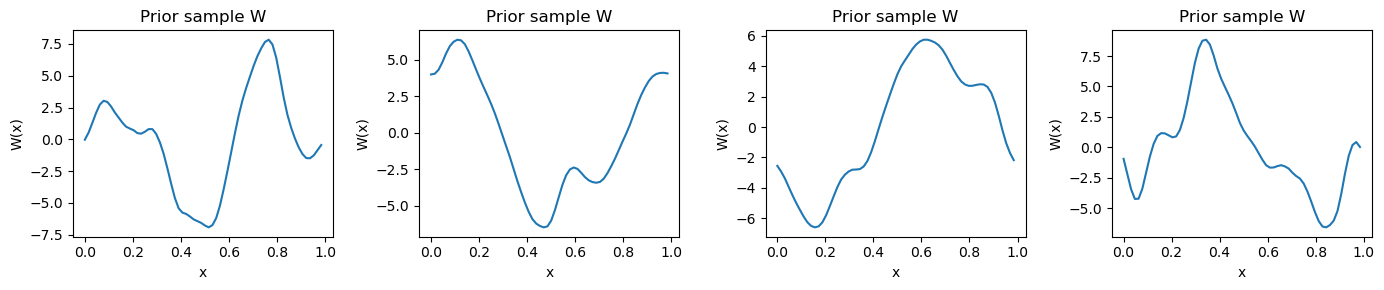

In [79]:
# Visualise a few prior samples of W
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
x_plot = np.linspace(0, 1, data_train_resolution, endpoint=False)
for ax in axes:
    W_sample = sample_W_prior(N=data_train_resolution)
    ax.plot(x_plot, W_sample)
    ax.set_xlabel("x")
    ax.set_ylabel("W(x)")
    ax.set_title("Prior sample W")
plt.tight_layout()
plt.show()


In [80]:
# Get a test observation: true rho(x,t) for one sample
W_true_np, rho_true_np = get_resolution(dataset, data_train_resolution)
W_true_np   = W_true_np[data_n_train-1]    # first test sample, shape (N,)
rho_true_np = rho_true_np[data_n_train-1]  # shape (N, N)

N = data_train_resolution
true_observations = torch.tensor(
    rho_true_np[np.newaxis, np.newaxis, :, :], dtype=torch.float32
).to(device)  # (1, 1, N, N)

sigma = float(true_observations.std())

# Initial MCMC state
u_0    = sample_W_prior(N=N)
W_tensor_0 = W_to_tensor(u_0, N, device)
theta_evolution = [u_0]
loss_evolution  = []
accepted        = []


In [81]:
from collections import deque

# === MCMC HYPERPARAMETERS ===
MCMC_delta        = 0.00025
MCMC_n_iterations = 40_000

target_acceptance = 0.234
adapt_interval    = 500
adapt_cutoff      = 20_000
delta_min, delta_max = 1e-6, 0.49

nll_window        = deque(maxlen=200)
n_accepted_window = 0
adapting          = True

theta_evolution = []
loss_evolution  = []
accepted        = []

# Observed rho (use test resolution)
W_obs_np, rho_obs_np = get_resolution(dataset, data_train_resolution)
W_obs_np   = W_obs_np[data_n_train]
rho_obs_np = rho_obs_np[data_n_train]
true_observations = torch.tensor(
    rho_obs_np[np.newaxis, np.newaxis, :, :], dtype=torch.float32
).to(device)

u_0        = sample_W_prior(N=data_train_resolution)
W_current  = W_to_tensor(u_0, data_train_resolution, device)
ll_current = log_likelihood(W_current, true_observations, model, sigma=sigma)

for i in range(MCMC_n_iterations):
    # pCN proposal on W
    u_proposal = (np.sqrt(1 - 2 * MCMC_delta) * u_0
                  + np.sqrt(2 * MCMC_delta) * sample_W_prior(N=data_train_resolution))
    W_proposal = W_to_tensor(u_proposal, data_train_resolution, device)

    ll_proposal     = log_likelihood(W_proposal, true_observations, model, sigma=sigma)
    acceptance_prob = min(1, np.exp(ll_proposal - ll_current))

    if np.random.rand() < acceptance_prob:
        u_0        = u_proposal
        W_current  = W_proposal
        ll_current = ll_proposal
        accepted.append(1)
        n_accepted_window += 1
    else:
        accepted.append(0)

    theta_evolution.append(u_0.copy())
    loss_evolution.append(ll_current)
    nll_window.append(-ll_current)

    if (i + 1) % adapt_interval == 0:
        acceptance_rate   = n_accepted_window / adapt_interval
        n_accepted_window = 0
        if adapting:
            factor     = np.exp(acceptance_rate - target_acceptance)
            MCMC_delta = float(np.clip(MCMC_delta * factor, delta_min, delta_max))
            if (i + 1) >= adapt_cutoff:
                adapting = False
                print(f">>> Adaptation frozen at delta={MCMC_delta:.6f}")
        avg_nll = np.mean(nll_window)
        print(f"Iteration {i+1}/{MCMC_n_iterations} | "
              f"accept={acceptance_rate:.3f} | delta={MCMC_delta:.6f} | "
              f"adapting={adapting} | avg NLL={avg_nll:.3f}")


Iteration 500/40000 | accept=0.922 | delta=0.000497 | adapting=True | avg NLL=130.638
Iteration 1000/40000 | accept=0.934 | delta=0.001002 | adapting=True | avg NLL=128.383
Iteration 1500/40000 | accept=0.930 | delta=0.002009 | adapting=True | avg NLL=127.171
Iteration 2000/40000 | accept=0.624 | delta=0.002967 | adapting=True | avg NLL=38.549
Iteration 2500/40000 | accept=0.206 | delta=0.002886 | adapting=True | avg NLL=12.851
Iteration 3000/40000 | accept=0.206 | delta=0.002806 | adapting=True | avg NLL=13.047
Iteration 3500/40000 | accept=0.302 | delta=0.003003 | adapting=True | avg NLL=12.236
Iteration 4000/40000 | accept=0.262 | delta=0.003089 | adapting=True | avg NLL=12.503
Iteration 4500/40000 | accept=0.246 | delta=0.003126 | adapting=True | avg NLL=12.650
Iteration 5000/40000 | accept=0.210 | delta=0.003052 | adapting=True | avg NLL=12.361
Iteration 5500/40000 | accept=0.270 | delta=0.003164 | adapting=True | avg NLL=13.472
Iteration 6000/40000 | accept=0.214 | delta=0.003101

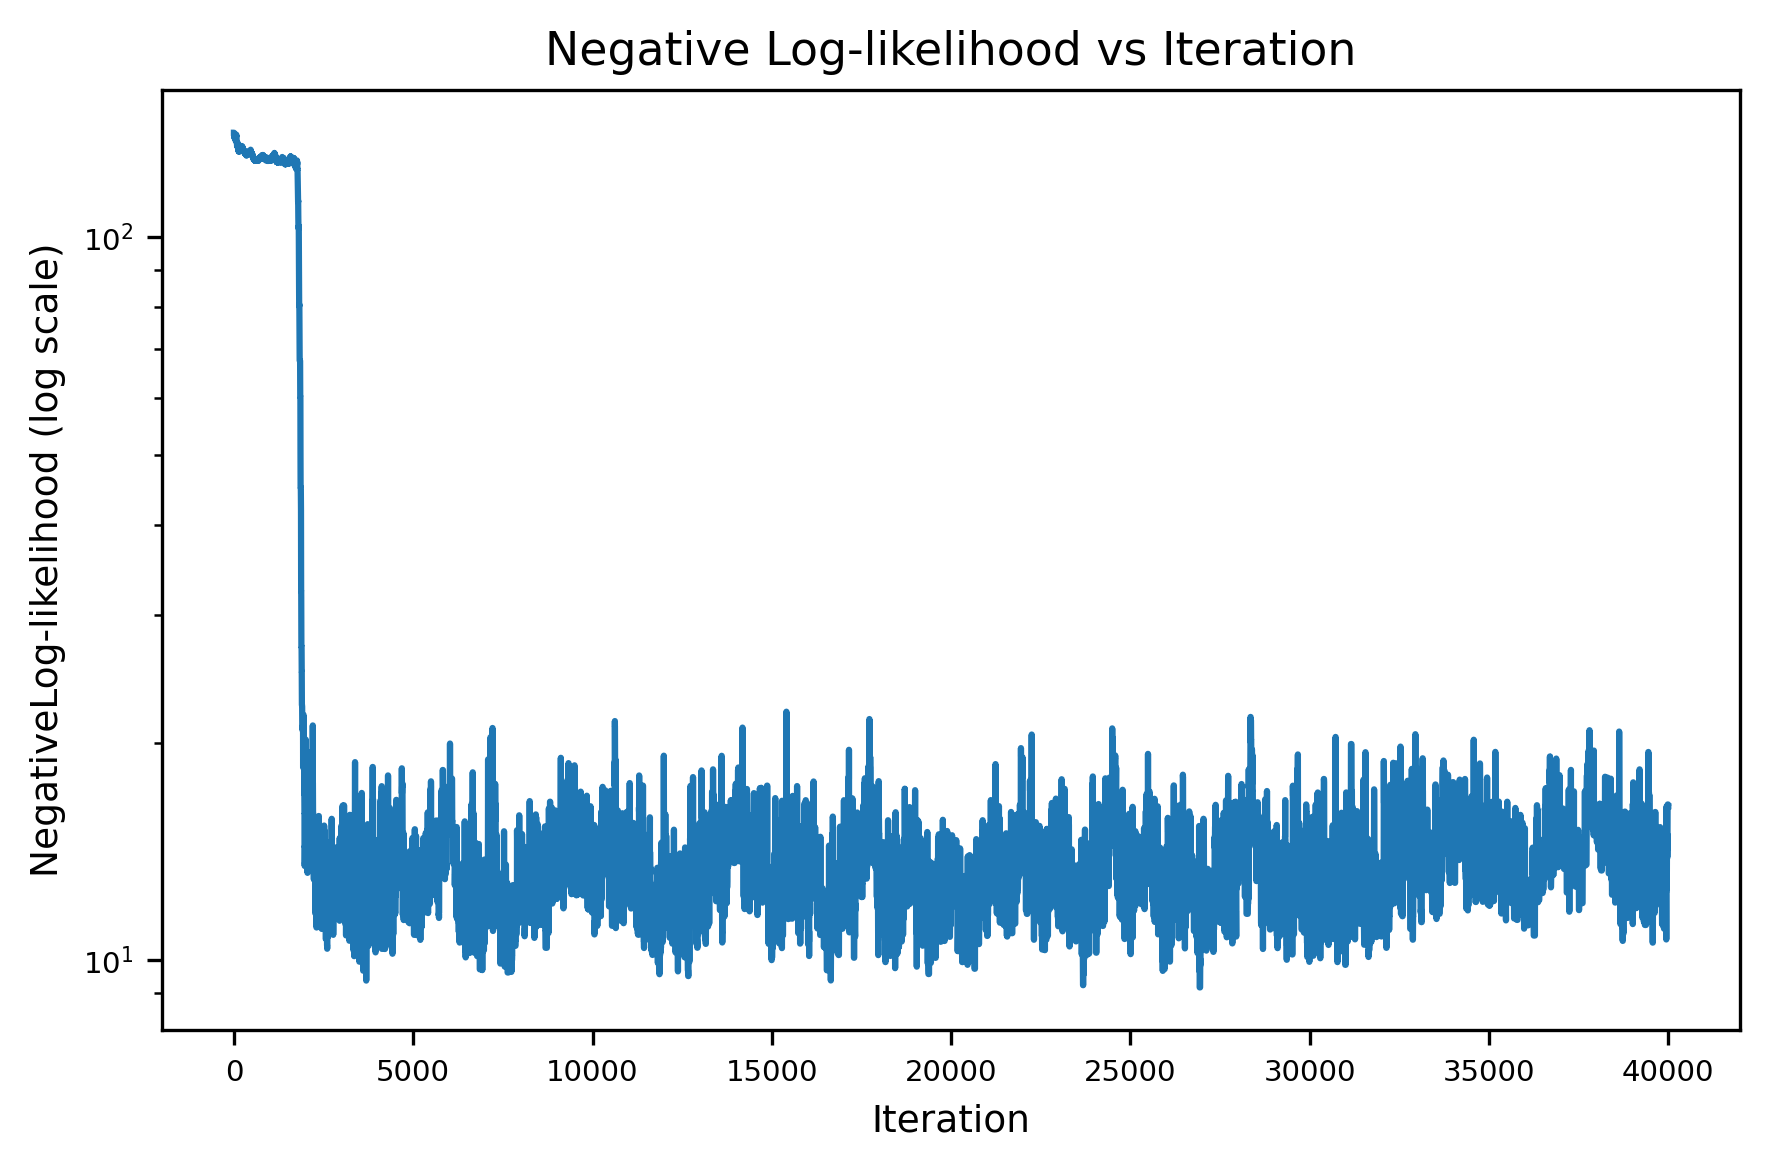

In [82]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)
ax.plot(-np.array(loss_evolution))
ax.set_yscale('log')
ax.set_title("Negative Log-likelihood vs Iteration", fontsize=11, loc='center', pad=6)
ax.set_xlabel("Iteration", fontsize=9)
ax.set_ylabel("NegativeLog-likelihood (log scale)", fontsize=9)
ax.tick_params(labelsize=7)
plt.tight_layout()
# plt.savefig('figures_for_report/loss_curve.png', bbox_inches='tight', dpi=300)
plt.show()

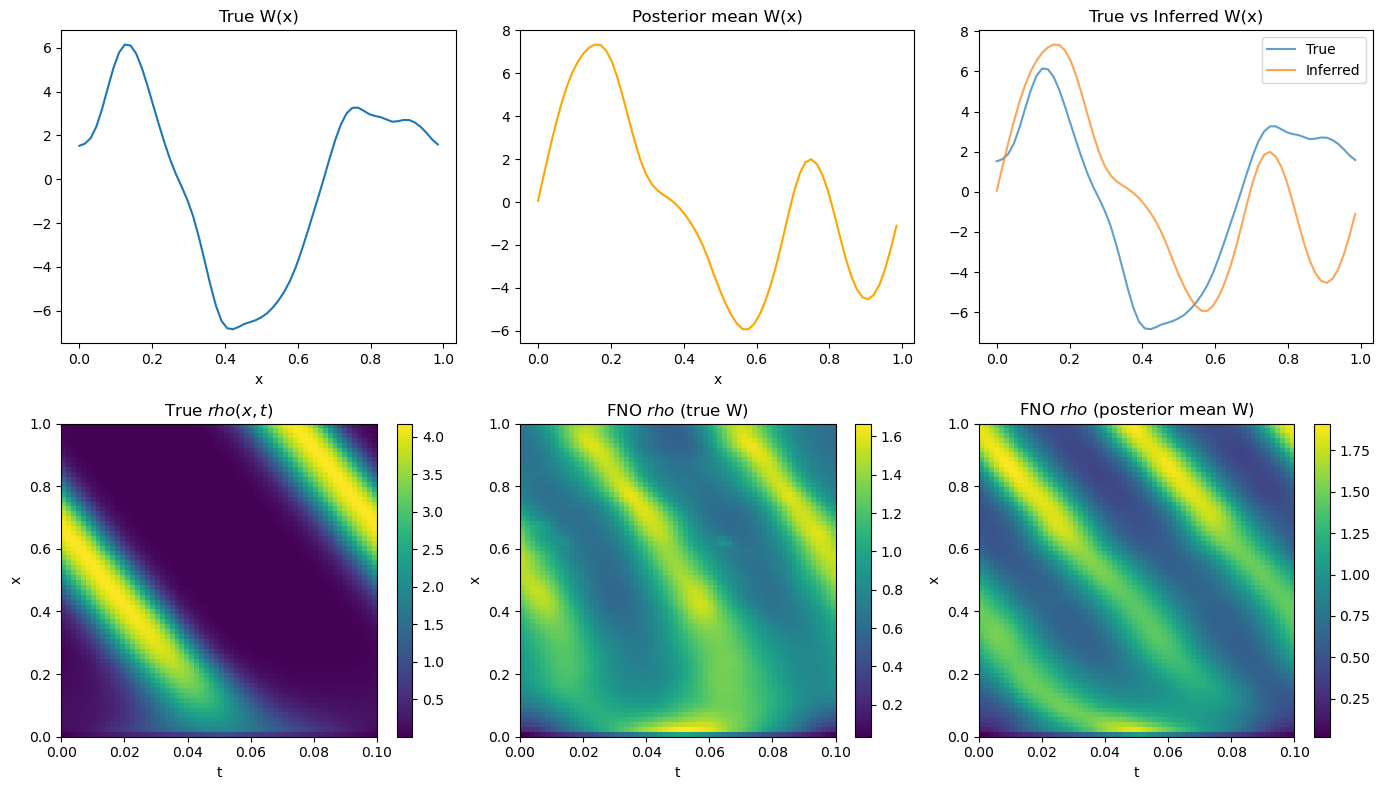

In [83]:
# Posterior mean of W
burnin = MCMC_n_iterations // 2
W_posterior_mean = np.mean(theta_evolution[burnin:], axis=0)  # shape (N,)

x_plot = np.linspace(0, 1, data_train_resolution, endpoint=False)

# FNO prediction under posterior mean W
W_mean_tensor = W_to_tensor(W_posterior_mean, data_train_resolution, device)
with torch.no_grad():
    rho_predicted = model(W_mean_tensor).cpu().numpy()[0, 0]  # (N, N)

# FNO prediction under true W
W_true_tensor = W_to_tensor(W_obs_np, data_train_resolution, device)
with torch.no_grad():
    rho_fno_true = model(W_true_tensor).cpu().numpy()[0, 0]  # (N, N)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Row 1: interaction potentials
axes[0, 0].plot(x_plot, W_obs_np, label="True W")
axes[0, 0].set_title("True W(x)")
axes[0, 0].set_xlabel("x")

axes[0, 1].plot(x_plot, W_posterior_mean, label="Posterior mean", color="orange")
axes[0, 1].set_title("Posterior mean W(x)")
axes[0, 1].set_xlabel("x")

axes[0, 2].plot(x_plot, W_obs_np, label="True", alpha=0.7)
axes[0, 2].plot(x_plot, W_posterior_mean, label="Inferred", alpha=0.7)
axes[0, 2].legend()
axes[0, 2].set_title("True vs Inferred W(x)")

# Row 2: rho(x,t) spacetime fields
extent = [0, 0.1, 0, 1]  # [t_min, t_max, x_min, x_max]
im0 = axes[1, 0].imshow(rho_true_np, aspect="auto", origin="lower", extent=extent)
axes[1, 0].set_title(r"True $rho(x,t)$")
axes[1, 0].set_xlabel("t"); axes[1, 0].set_ylabel("x")
plt.colorbar(im0, ax=axes[1, 0])

im1 = axes[1, 1].imshow(rho_fno_true, aspect="auto", origin="lower", extent=extent)
axes[1, 1].set_title(r"FNO $rho$ (true W)")
axes[1, 1].set_xlabel("t"); axes[1, 1].set_ylabel("x")
plt.colorbar(im1, ax=axes[1, 1])

im2 = axes[1, 2].imshow(rho_predicted, aspect="auto", origin="lower", extent=extent)
axes[1, 2].set_title(r"FNO $rho$ (posterior mean W)")
axes[1, 2].set_xlabel("t"); axes[1, 2].set_ylabel("x")
plt.colorbar(im2, ax=axes[1, 2])

plt.tight_layout()
plt.show()

In [84]:
# Quantitative errors
rho_obs_tensor = torch.tensor(rho_obs_np[np.newaxis, np.newaxis], dtype=torch.float32)
rho_pred_tensor = torch.tensor(rho_predicted[np.newaxis, np.newaxis], dtype=torch.float32)
rho_fno_tensor  = torch.tensor(rho_fno_true[np.newaxis, np.newaxis], dtype=torch.float32)

print("--- FNO under true W (best possible) ---")
print(f"H1: {h1loss(rho_fno_tensor, rho_obs_tensor).item():.4f}")
print(f"L2: {l2loss(rho_fno_tensor, rho_obs_tensor).item():.4f}")

print("--- FNO under posterior mean W ---")
print(f"H1: {h1loss(rho_pred_tensor, rho_obs_tensor).item():.4f}")
print(f"L2: {l2loss(rho_pred_tensor, rho_obs_tensor).item():.4f}")


--- FNO under true W (best possible) ---
H1: 1.2130
L2: 0.4588
--- FNO under posterior mean W ---
H1: 0.2631
L2: 0.0976


In [85]:
# NLL under true W vs posterior mean W
W_true_tensor_dev = W_to_tensor(W_obs_np, data_train_resolution, device)
ll_true = log_likelihood(W_true_tensor_dev, true_observations, model, sigma=sigma)
print(f"NLL with true W:          {-ll_true:.4f}")
print(f"NLL with posterior mean W: {-ll_current:.4f}")


NLL with true W:          270.9744
NLL with posterior mean W: 16.3331


L2 error on W: 3.5036


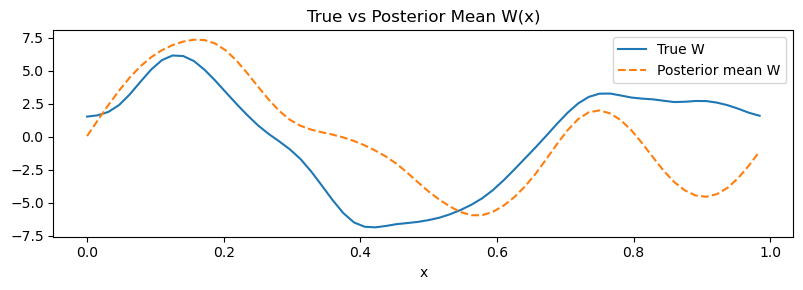

In [86]:
# L2 error on W itself
W_err = np.mean((W_posterior_mean - W_obs_np)**2)**0.5
print(f"L2 error on W: {W_err:.4f}")

plt.figure(figsize=(8, 3))
plt.plot(x_plot, W_obs_np, label="True W")
plt.plot(x_plot, W_posterior_mean, label="Posterior mean W", linestyle="--")
plt.legend()
plt.title("True vs Posterior Mean W(x)")
plt.xlabel("x")
plt.tight_layout()
plt.show()


In [87]:
# Estimate a reasonable sigma from FNO error on true W
with torch.no_grad():
    rho_pred_true = model(W_to_tensor(W_obs_np, data_train_resolution, device))
    residuals = true_observations - rho_pred_true
    print(f"Suggested sigma: {residuals.std().item():.4f}")


Suggested sigma: 0.4833


Text(0.5, 1.0, 'Mean absolute change per step')

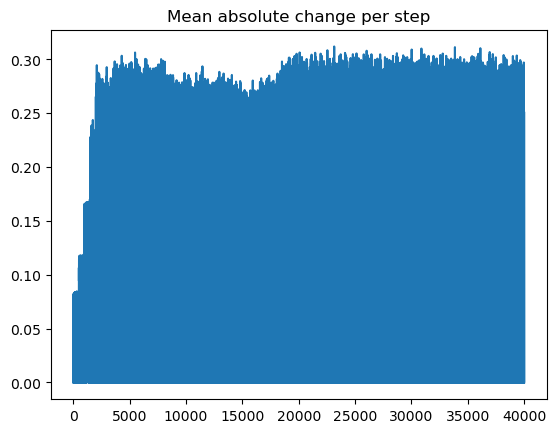

In [88]:
# Plot how much the chain moves each step
diffs = [np.mean(np.abs(theta_evolution[i] - theta_evolution[i-1])) 
         for i in range(1, len(theta_evolution))]
plt.plot(diffs)
plt.title("Mean absolute change per step")

In [89]:
print(f"sigma = {sigma:.4f}")
print(f"rho range: [{rho_obs_np.min():.4f}, {rho_obs_np.max():.4f}]")

sigma = 1.3284
rho range: [0.0001, 1.9764]


In [90]:
# How different are two random W's rho outputs?
W1 = sample_W_prior(N=data_train_resolution)
W2 = sample_W_prior(N=data_train_resolution)
with torch.no_grad():
    r1 = model(W_to_tensor(W1, data_train_resolution, device)).cpu().numpy()[0,0]
    r2 = model(W_to_tensor(W2, data_train_resolution, device)).cpu().numpy()[0,0]
print(f"Mean |rho1 - rho2|: {np.mean(np.abs(r1 - r2)):.4f}")
print(f"Mean |rho_true - rho1|: {np.mean(np.abs(rho_obs_np - r1)):.4f}")

Mean |rho1 - rho2|: 0.8877
Mean |rho_true - rho1|: 0.6773


In [91]:
# Test what sigma_W you need
for sigma_W in [0.1, 0.5, 1.0, 2.0, 5.0]:
    W1 = sample_negative_laplacian(sigma=sigma_W, tau=3, alpha=4, N=data_train_resolution)
    W2 = sample_negative_laplacian(sigma=sigma_W, tau=3, alpha=4, N=data_train_resolution)
    with torch.no_grad():
        r1 = model(W_to_tensor(W1, data_train_resolution, device)).cpu().numpy()[0,0]
        r2 = model(W_to_tensor(W2, data_train_resolution, device)).cpu().numpy()[0,0]
    print(f"sigma_W={sigma_W:.1f} | |rho1-rho2|={np.mean(np.abs(r1-r2)):.4f}")

sigma_W=0.1 | |rho1-rho2|=0.0060
sigma_W=0.5 | |rho1-rho2|=0.0532
sigma_W=1.0 | |rho1-rho2|=0.2548
sigma_W=2.0 | |rho1-rho2|=0.4757
sigma_W=5.0 | |rho1-rho2|=0.2098
